<h1><center>VAE</center></h1>

<h1><center>Часть 1. Теория</center></h1>

В процессе обучения изменяется размещение объектов в латентном пространстве.

Рассмотрим выход слоя перед классификацией для модели обученной на рукописных цифрах MNIST:

In [1]:
from torchvision import datasets
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import torchvision
import matplotlib.pyplot as plt

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

transform = transforms.Compose([
        transforms.ToTensor()
    ])

dataset = datasets.MNIST(
    '.',
    train=True,
    download=True,
    transform=transform
)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 3.92MB/s]


Extracting .\MNIST\raw\train-images-idx3-ubyte.gz to .\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 215kB/s]


Extracting .\MNIST\raw\train-labels-idx1-ubyte.gz to .\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 1.71MB/s]


Extracting .\MNIST\raw\t10k-images-idx3-ubyte.gz to .\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.26MB/s]

Extracting .\MNIST\raw\t10k-labels-idx1-ubyte.gz to .\MNIST\raw



Расстояние между объектами на входе моделей (исходные картинки) попиксельно не позволяяет увидеть классификацию . Например для объектов 3 и 1:

Расстояние между классами по пикселям 3 и 1
0.08597984164953232


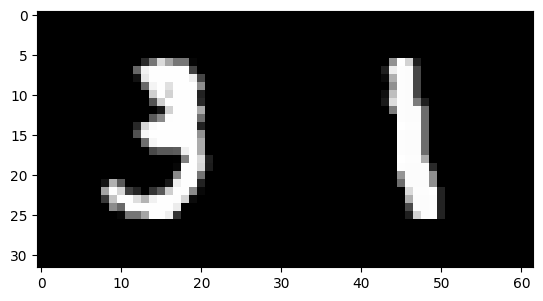

In [3]:
img_1, label_1 = dataset[10]
img_2, label_2 = dataset[6]

print(f'Расстояние между классами по пикселям {label_1} и {label_2}')
print(torch.mean(torch.square(img_1 - img_2)).item())

grid = torchvision.utils.make_grid([img_1, img_2])
plt.imshow(grid.permute(1, 2, 0));

или объектов 3 и 3:

Расстояние между классами по пикселям 3 и 3
0.11974499374628067


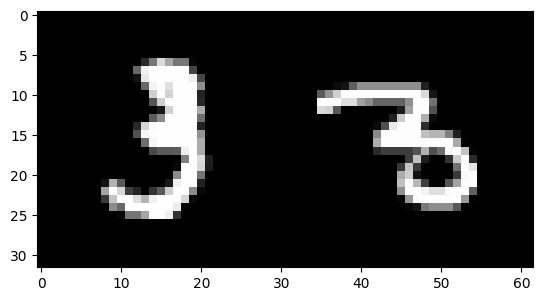

In [4]:
img_3, label_3 = dataset[30]

print(f'Расстояние между классами по пикселям {label_1} и {label_3}')
print(torch.mean(torch.square(img_1 - img_3)).item())

grid = torchvision.utils.make_grid([img_1, img_3])
plt.imshow(grid.permute(1, 2, 0));

Соберем классификатор для решения проблемы классификации рукописных цифр. 10 класов на выходе. картинка на входе. Из ссети будем возвращать класс и выход предпоследнгего слоя (эмбеддинг):

In [5]:
class TinyModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1,
                               out_channels=4,
                               kernel_size=3)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=4,
                               out_channels=8,
                               kernel_size=3)
        self.fc1 = nn.Linear(in_features=200,
                             out_features=128)
        self.fc2 = nn.Linear(in_features=128,
                             out_features=num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.pool(x)
        x = self.relu(x)
        x = x.reshape((-1, 200))
        emb = self.fc1(x)
        x = self.fc2(emb)
        return x, emb

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TinyModel(10).to(device)

оценим выходы модели (эмбеддинги) и входы моделей (картинки) с точки зрения разделимости классов до обучения через PCA(https://scikit-learn.ru/stable/modules/decomposition.html, https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), tSNE( https://scikit-learn.ru/stable/modules/manifold.html, https://scikit-learn.ru/stable/modules/generated/sklearn.manifold.TSNE.html#sklearn.manifold.TSNE) :


In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
def plot_latent_class(model, data, num_batches=100, device=device):
    plt.figure(figsize=(10, 8))
    # tsne = TSNE(n_components=2)
    pca = PCA(n_components=2)
    rez = []
    rez_y = []
    for i, (x, y) in enumerate(data):
        predict_y, z = model(x.to(device))
        z = z.to('cpu').detach().numpy()
        rez.extend(z.tolist())
        rez_y.extend(y.tolist())
        if i > num_batches:
            break
    # Z = tsne.fit_transform(np.array(rez))
    Z =  pca.fit_transform(np.array(rez))
    plt.scatter(Z[:, 0], Z[:, 1], c=rez_y, cmap='tab10')

    plt.colorbar()
    plt.show()


In [8]:
def plot_image_class(model, data, num_batches=100, device=device):
    plt.figure(figsize=(10, 8))
    # tsne = TSNE(n_components=2)
    pca = PCA(n_components=2)
    rez = []
    rez_y = []
    for i, (x, y) in enumerate(data):
        z = x.reshape([-1, 784]).to('cpu').detach().numpy()
        rez.extend(z.tolist())
        rez_y.extend(y.tolist())
        if i > num_batches:
            break
    # Z = tsne.fit_transform(np.array(rez))
    Z =  pca.fit_transform(np.array(rez))
    plt.scatter(Z[:, 0], Z[:, 1], c=rez_y, cmap='tab10')

    plt.colorbar()
    plt.show()

In [9]:
data_test = torch.utils.data.DataLoader(
       torchvision.datasets.MNIST('./',train=False,
               transform=torchvision.transforms.ToTensor(),
               download=True),
       batch_size=256,
       shuffle=True)

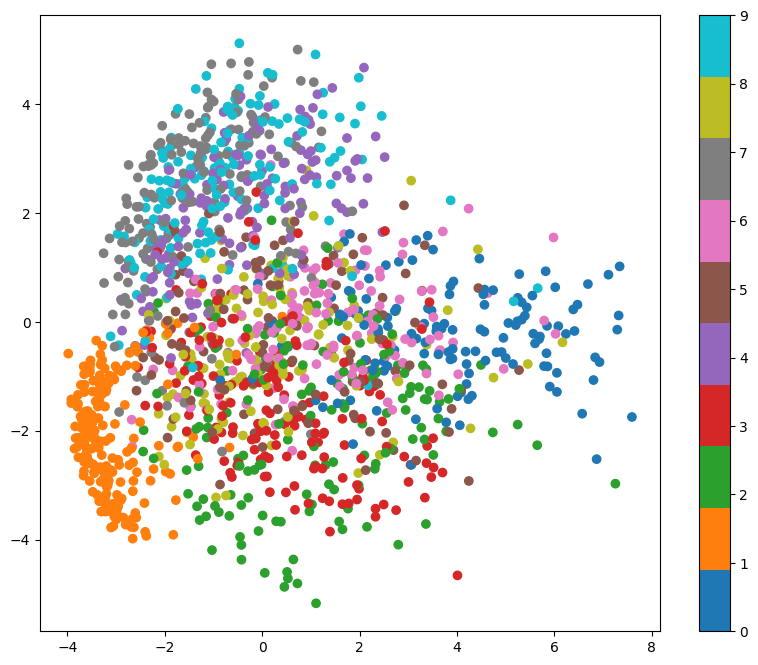

In [10]:
plot_image_class(model, data_test, num_batches=4)

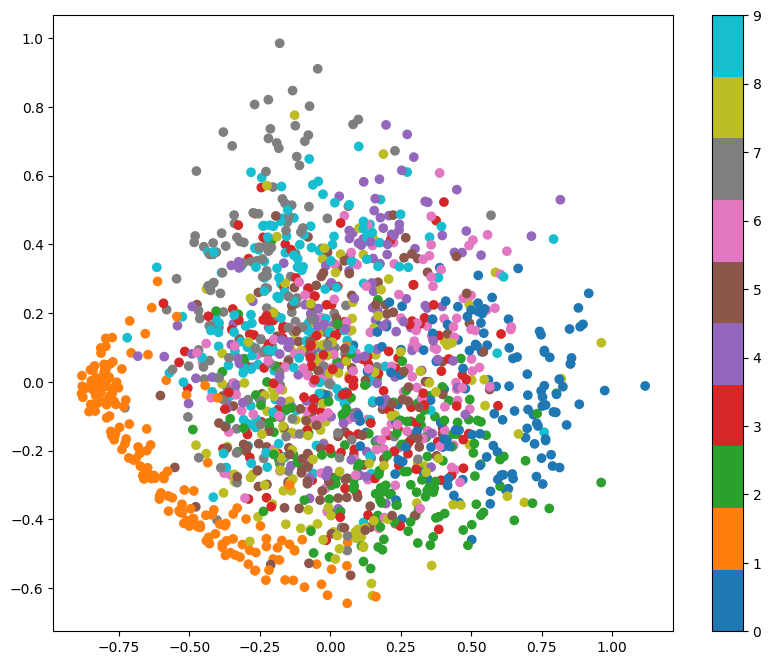

In [11]:
plot_latent_class(model, data_test, num_batches=4)

 ## Задание 1.
    1.1ю Получите результат преобразования для визуализации данных (2 компоненты) по РСА входных картинок  (каждую картинку преобразовать в вектор, на 1000 картинок сделать РСА, оценить результат на визуальном уровне через разметку по меткам картинок (классам) из датасет)
    1.2. Для тех же картинок получить результат визуализации данных (2 компоненты) РСА над вектором эмбеддинга в необученной модели и оценить результат визуально (видны группы/не ивдны группы)
    1.3. повторить 1.2 и 1.1 для визуализации с TSNE (или UMAP) на 2 компоненты
    1.4. посмотреть на https://projector.tensorflow.org/ - посмотреть на эмбединги из "рукописных цифр" (DATA : MNIST with images) для PCA, tSNE, UMAP
    1.5. Объяснить почему не видим классы на входных картинка и  эмбеддингах для необученных моделей через РСА и видим черех tSNE

In [ ]:
# Задание 1.1: PCA для входных картинок (1000 картинок)
def plot_image_class_pca_1000(data, num_samples=1000, device=device):
    """Визуализация входных картинок через PCA на 1000 образцах"""
    plt.figure(figsize=(10, 8))
    pca = PCA(n_components=2)
    rez = []
    rez_y = []
    count = 0
    
    for i, (x, y) in enumerate(data):
        z = x.reshape([-1, 784]).to('cpu').detach().numpy()
        rez.extend(z.tolist())
        rez_y.extend(y.tolist())
        count += len(y)
        if count >= num_samples:
            break
    
    # Ограничиваем до 1000 образцов
    rez = rez[:num_samples]
    rez_y = rez_y[:num_samples]
    
    Z = pca.fit_transform(np.array(rez))
    plt.scatter(Z[:, 0], Z[:, 1], c=rez_y, cmap='tab10', alpha=0.6)
    plt.colorbar(label='Класс')
    plt.title('PCA визуализация входных картинок (1000 образцов)')
    plt.xlabel('Первая главная компонента')
    plt.ylabel('Вторая главная компонента')
    plt.show()
    
    return Z, rez_y

# Выполняем задание 1.1
print("Задание 1.1: PCA для входных картинок")
Z_images_pca, labels_images = plot_image_class_pca_1000(data_test, num_samples=1000)


In [ ]:
# Задание 1.2: PCA для эмбеддингов необученной модели (1000 картинок)
def plot_latent_class_pca_1000(model, data, num_samples=1000, device=device):
    """Визуализация эмбеддингов необученной модели через PCA на 1000 образцах"""
    plt.figure(figsize=(10, 8))
    pca = PCA(n_components=2)
    rez = []
    rez_y = []
    count = 0
    
    for i, (x, y) in enumerate(data):
        predict_y, z = model(x.to(device))
        z = z.to('cpu').detach().numpy()
        rez.extend(z.tolist())
        rez_y.extend(y.tolist())
        count += len(y)
        if count >= num_samples:
            break
    
    # Ограничиваем до 1000 образцов
    rez = rez[:num_samples]
    rez_y = rez_y[:num_samples]
    
    Z = pca.fit_transform(np.array(rez))
    plt.scatter(Z[:, 0], Z[:, 1], c=rez_y, cmap='tab10', alpha=0.6)
    plt.colorbar(label='Класс')
    plt.title('PCA визуализация эмбеддингов необученной модели (1000 образцов)')
    plt.xlabel('Первая главная компонента')
    plt.ylabel('Вторая главная компонента')
    plt.show()
    
    return Z, rez_y

# Выполняем задание 1.2
print("Задание 1.2: PCA для эмбеддингов необученной модели")
# Создаем новую необученную модель для задания
model_untrained = TinyModel(10).to(device)
Z_embeddings_pca, labels_embeddings = plot_latent_class_pca_1000(model_untrained, data_test, num_samples=1000)


In [ ]:
# Задание 1.3: tSNE для входных картинок (1000 картинок)
def plot_image_class_tsne_1000(data, num_samples=1000, device=device):
    """Визуализация входных картинок через tSNE на 1000 образцах"""
    plt.figure(figsize=(10, 8))
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    rez = []
    rez_y = []
    count = 0
    
    for i, (x, y) in enumerate(data):
        z = x.reshape([-1, 784]).to('cpu').detach().numpy()
        rez.extend(z.tolist())
        rez_y.extend(y.tolist())
        count += len(y)
        if count >= num_samples:
            break
    
    # Ограничиваем до 1000 образцов
    rez = rez[:num_samples]
    rez_y = rez_y[:num_samples]
    
    print("Выполняется tSNE для входных картинок... (это может занять некоторое время)")
    Z = tsne.fit_transform(np.array(rez))
    plt.scatter(Z[:, 0], Z[:, 1], c=rez_y, cmap='tab10', alpha=0.6)
    plt.colorbar(label='Класс')
    plt.title('tSNE визуализация входных картинок (1000 образцов)')
    plt.xlabel('Первая компонента tSNE')
    plt.ylabel('Вторая компонента tSNE')
    plt.show()
    
    return Z, rez_y

# Выполняем задание 1.3 (часть 1 - входные картинки)
print("Задание 1.3 (часть 1): tSNE для входных картинок")
Z_images_tsne, labels_images_tsne = plot_image_class_tsne_1000(data_test, num_samples=1000)


In [ ]:
# Задание 1.3: tSNE для эмбеддингов необученной модели (1000 картинок)
def plot_latent_class_tsne_1000(model, data, num_samples=1000, device=device):
    """Визуализация эмбеддингов необученной модели через tSNE на 1000 образцах"""
    plt.figure(figsize=(10, 8))
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    rez = []
    rez_y = []
    count = 0
    
    for i, (x, y) in enumerate(data):
        predict_y, z = model(x.to(device))
        z = z.to('cpu').detach().numpy()
        rez.extend(z.tolist())
        rez_y.extend(y.tolist())
        count += len(y)
        if count >= num_samples:
            break
    
    # Ограничиваем до 1000 образцов
    rez = rez[:num_samples]
    rez_y = rez_y[:num_samples]
    
    print("Выполняется tSNE для эмбеддингов... (это может занять некоторое время)")
    Z = tsne.fit_transform(np.array(rez))
    plt.scatter(Z[:, 0], Z[:, 1], c=rez_y, cmap='tab10', alpha=0.6)
    plt.colorbar(label='Класс')
    plt.title('tSNE визуализация эмбеддингов необученной модели (1000 образцов)')
    plt.xlabel('Первая компонента tSNE')
    plt.ylabel('Вторая компонента tSNE')
    plt.show()
    
    return Z, rez_y

# Выполняем задание 1.3 (часть 2 - эмбеддинги)
print("Задание 1.3 (часть 2): tSNE для эмбеддингов необученной модели")
Z_embeddings_tsne, labels_embeddings_tsne = plot_latent_class_tsne_1000(model_untrained, data_test, num_samples=1000)


### Задание 1.4: TensorFlow Projector

Для визуализации эмбеддингов MNIST на https://projector.tensorflow.org/:

1. Перейдите на сайт: https://projector.tensorflow.org/
2. Выберите DATA: "MNIST with images"
3. Попробуйте различные методы визуализации:
   - PCA (Principal Component Analysis)
   - tSNE (t-distributed Stochastic Neighbor Embedding)
   - UMAP (Uniform Manifold Approximation and Projection)

Это позволит интерактивно исследовать, как различные методы снижения размерности визуализируют структуру данных MNIST.


### Задание 1.5: Объяснение различий между PCA и tSNE

**Почему не видим классы на входных картинках и эмбеддингах для необученных моделей через PCA, но видим через tSNE:**

1. **PCA (Principal Component Analysis)**:
   - Линейный метод снижения размерности
   - Ищет направления максимальной дисперсии в данных
   - Для необученных моделей эмбеддинги представляют случайные веса, поэтому структура данных не отражает семантические различия между классами
   - На входных картинках PCA видит только пиксельные различия, которые не обязательно соответствуют классам (например, две цифры "3" могут быть более разными по пикселям, чем "3" и "1")
   - PCA не может выявить нелинейные структуры в данных

2. **tSNE (t-distributed Stochastic Neighbor Embedding)**:
   - Нелинейный метод снижения размерности
   - Сохраняет локальные структуры и соседство точек
   - Даже для случайных данных может выявить некоторые кластеры благодаря сохранению локальных расстояний
   - Более чувствителен к локальным структурам, что может помочь увидеть группы даже в необученных эмбеддингах
   - Однако для необученных моделей группы могут быть менее четкими, чем после обучения

**Вывод**: PCA работает с глобальной структурой данных и линейными зависимостями, в то время как tSNE фокусируется на локальных структурах и нелинейных зависимостях, что позволяет лучше визуализировать кластеры даже в данных без явной семантической структуры.


Обучаем:

In [12]:
def train(model, dataloader, device=device):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    model.to(device)
    for epoch in range(5):
        for step, (imgs, labels) in enumerate(dataloader):
            imgs, labels = imgs.to(device), labels.to(device)

            pred, _ = model(imgs)

            loss = criterion(pred, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if step % 100 == 0:
                print(f'Loss is {loss.item()}')

    return model

Обучаем:

In [13]:
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=256,
    shuffle=True
)

In [14]:
model = TinyModel(10)
model = train(model, dataloader)

Loss is 2.3078770637512207
Loss is 0.6101128458976746
Loss is 0.34492623805999756
Loss is 0.3201090097427368
Loss is 0.2772781252861023
Loss is 0.21278294920921326
Loss is 0.14666253328323364
Loss is 0.19036145508289337
Loss is 0.22385841608047485
Loss is 0.17515218257904053
Loss is 0.18721675872802734
Loss is 0.1776781678199768
Loss is 0.09366084635257721
Loss is 0.14795944094657898
Loss is 0.15428218245506287


In [15]:
model.to('cpu')
_, emb_1 = model(img_1[None])
_, emb_2 = model(img_2[None])
_, emb_3 = model(img_3[None])

In [16]:
print(f'Расстояние между классами {label_1} и {label_2}')
print(torch.mean(torch.square(emb_1 - emb_2)).item())

print(f'Расстояние между классами {label_1} и {label_3}')
print(torch.mean(torch.square(emb_1 - emb_3)).item())

Расстояние между классами 3 и 1
1.329256296157837
Расстояние между классами 3 и 3
1.20138680934906


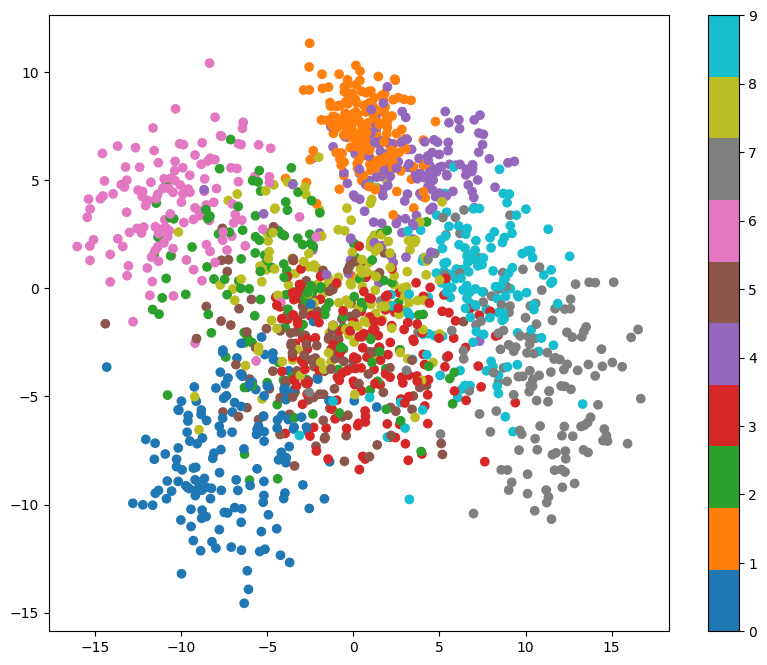

In [17]:
plot_latent_class(model.to(device), data_test, num_batches=4)

## Задание 2
    2.1 повторите анализ эмбеддингов для модели после обучения и сравните результаты по tSNE, PCA визуализациям

In [ ]:
# Задание 2.1: Анализ эмбеддингов для модели после обучения (PCA и tSNE)

# PCA для эмбеддингов обученной модели
print("Задание 2.1: PCA для эмбеддингов обученной модели")
Z_embeddings_pca_trained, labels_embeddings_trained = plot_latent_class_pca_1000(model, data_test, num_samples=1000)


In [ ]:
# tSNE для эмбеддингов обученной модели
print("Задание 2.1: tSNE для эмбеддингов обученной модели")
Z_embeddings_tsne_trained, labels_embeddings_tsne_trained = plot_latent_class_tsne_1000(model, data_test, num_samples=1000)


In [ ]:
# Сравнение результатов: визуализация PCA и tSNE для обученной модели
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
axes[0].scatter(Z_embeddings_pca_trained[:, 0], Z_embeddings_pca_trained[:, 1], 
                c=labels_embeddings_trained, cmap='tab10', alpha=0.6)
axes[0].set_title('PCA: Эмбеддинги обученной модели (1000 образцов)')
axes[0].set_xlabel('Первая главная компонента')
axes[0].set_ylabel('Вторая главная компонента')
axes[0].grid(True, alpha=0.3)

# tSNE
axes[1].scatter(Z_embeddings_tsne_trained[:, 0], Z_embeddings_tsne_trained[:, 1], 
                c=labels_embeddings_tsne_trained, cmap='tab10', alpha=0.6)
axes[1].set_title('tSNE: Эмбеддинги обученной модели (1000 образцов)')
axes[1].set_xlabel('Первая компонента tSNE')
axes[1].set_ylabel('Вторая компонента tSNE')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nСравнение результатов:")
print("После обучения модели эмбеддинги должны лучше разделяться по классам.")
print("PCA показывает линейные зависимости в данных, а tSNE - нелинейные структуры.")
print("Оба метода должны показывать более четкое разделение классов по сравнению с необученной моделью.")


Построим автоэнкодер для этого же примера, т.е. при обучении метки классов  будут не нужныю Визуализируем примеры и посмотрим ан качество разделения объектов в скрытом пространстве после обучения.


### Autoencoder


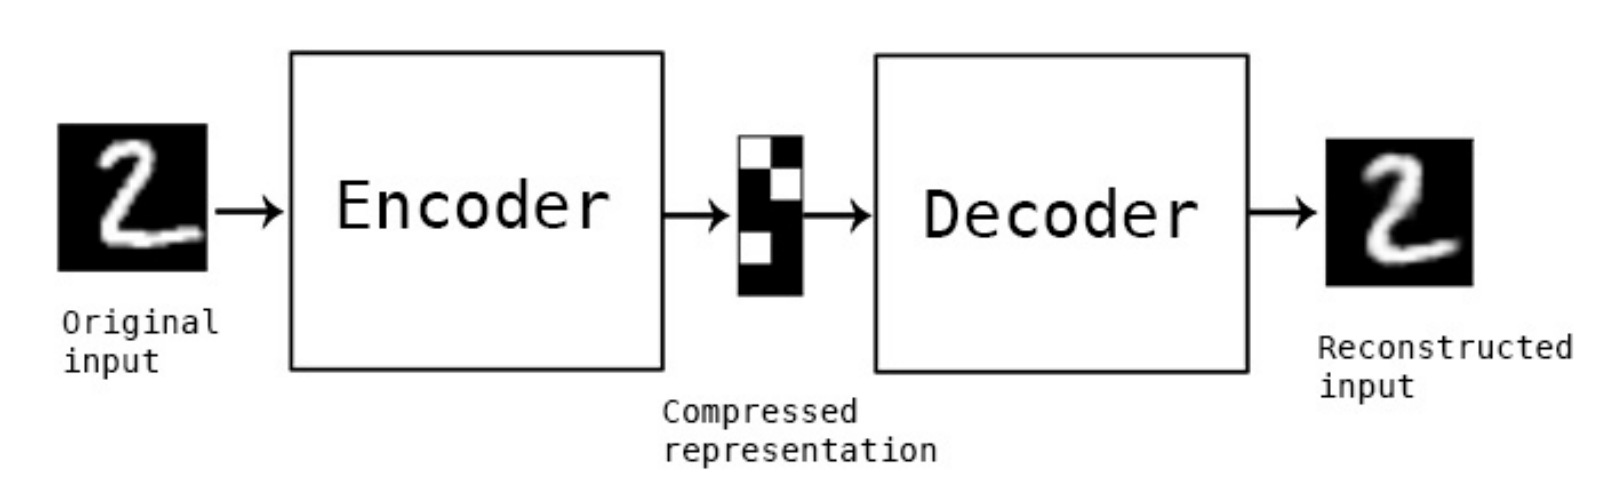

Функция потерь будет очень простой L2:

$$L = ||x_{out} - x_{in}||^2$$

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils
import torch.distributions
import torchvision
import numpy as np
import matplotlib.pyplot as plt

In [19]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Создадим класс Encoder, наследованный от torch.nn.Module.

In [20]:
class Encoder(nn.Module):
    def __init__(self, latent_dims):
        super(Encoder, self).__init__()
        self.linear1 = nn.Linear(784, 512)
        self.linear2 = nn.Linear(512, latent_dims)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        return self.linear2(x)

Создадим что-то похожее но теперь для декодера, главное, чтобы совпадала размерность выхода.



In [21]:
class Decoder(nn.Module):
    def __init__(self, latent_dims):
        super(Decoder, self).__init__()
        self.linear1 = nn.Linear(latent_dims, 512)
        self.linear2 = nn.Linear(512, 784)

    def forward(self, z):
        z = F.relu(self.linear1(z))
        z = torch.sigmoid(self.linear2(z))
        return z.reshape((-1, 1, 28, 28))

Напишем класс Autoencoder, который соединяет экнкодер и декодер.

In [22]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(latent_dims)
        self.decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [23]:
def train(autoencoder, data, epochs=20):
    opt = torch.optim.Adam(autoencoder.parameters())

    for epoch in range(epochs):
        for step, (x, _) in enumerate(data):
            x = x.to(device)
            opt.zero_grad()
            x_hat = autoencoder(x)
            loss = ((x - x_hat) ** 2).sum()
            loss.backward()
            opt.step()

            if step % 200 == 0:
                print(f'Epoch [{epoch+1}/{epochs}]. Step [{step}/{len(data)}]. Loss is {loss.item():.2f}')
    return autoencoder

In [24]:
latent_dims = 2 # размерность скрытого пространства удобная для визуализации
autoencoder = Autoencoder(latent_dims).to(device)

data = torch.utils.data.DataLoader(
       torchvision.datasets.MNIST('./',
               transform=torchvision.transforms.ToTensor(),
               download=True),
       batch_size=256,
       shuffle=True)

In [25]:
%%time
autoencoder = train(autoencoder, data)

Epoch [1/20]. Step [0/235]. Loss is 46980.98
Epoch [1/20]. Step [200/235]. Loss is 10837.44
Epoch [2/20]. Step [0/235]. Loss is 10275.16
Epoch [2/20]. Step [200/235]. Loss is 9843.15
Epoch [3/20]. Step [0/235]. Loss is 9921.77
Epoch [3/20]. Step [200/235]. Loss is 9042.97
Epoch [4/20]. Step [0/235]. Loss is 9346.23
Epoch [4/20]. Step [200/235]. Loss is 9262.02
Epoch [5/20]. Step [0/235]. Loss is 9387.65
Epoch [5/20]. Step [200/235]. Loss is 8931.28
Epoch [6/20]. Step [0/235]. Loss is 8665.82
Epoch [6/20]. Step [200/235]. Loss is 8913.10
Epoch [7/20]. Step [0/235]. Loss is 8840.77
Epoch [7/20]. Step [200/235]. Loss is 8639.46
Epoch [8/20]. Step [0/235]. Loss is 8915.50
Epoch [8/20]. Step [200/235]. Loss is 8827.32
Epoch [9/20]. Step [0/235]. Loss is 8667.30
Epoch [9/20]. Step [200/235]. Loss is 8930.11
Epoch [10/20]. Step [0/235]. Loss is 8624.26
Epoch [10/20]. Step [200/235]. Loss is 8418.65
Epoch [11/20]. Step [0/235]. Loss is 9075.37
Epoch [11/20]. Step [200/235]. Loss is 8866.63
Epo

Можем посмотреть на скрытое пространство, которое состоит из двух размерностей. Также у нас есть метки классов всех точек, поэтому можем их раскрасить.

In [26]:
def plot_latent(autoencoder, data, num_batches=100):
    plt.figure(figsize=(10, 8))
    for i, (x, y) in enumerate(data):
        z = autoencoder.encoder(x.to(device))
        z = z.to('cpu').detach().numpy()
        plt.scatter(z[:, 0], z[:, 1], c=y, cmap='tab10')
        if i > num_batches:
            plt.colorbar()
            break
    plt.colorbar()
    plt.show()

Наше скрытое представление отнесло изображения из одного класса в один кластер.

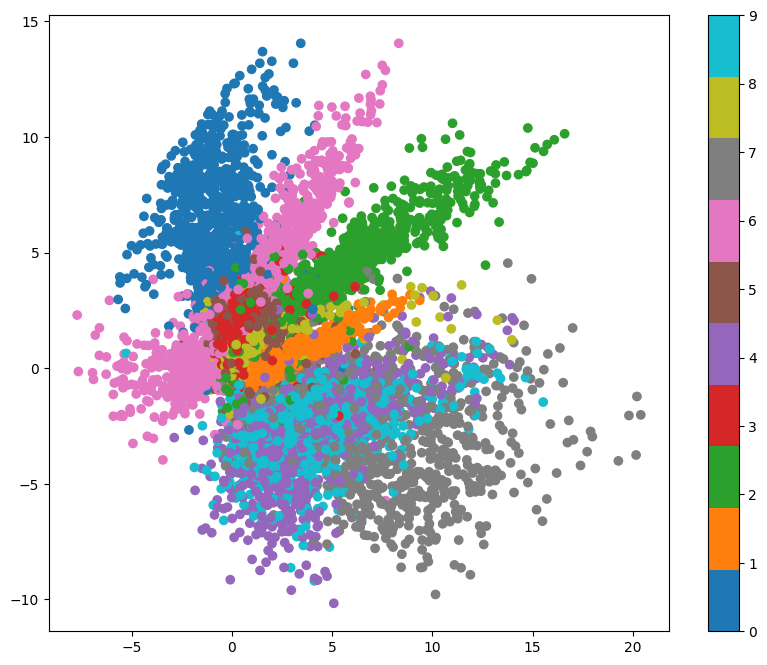

In [27]:
data_test = torch.utils.data.DataLoader(
       torchvision.datasets.MNIST('./',train=False,
               transform=torchvision.transforms.ToTensor(),
               download=True),
       batch_size=256,
       shuffle=False)
plot_latent(autoencoder, data_test)

Можем ещё насэмплировать точек из скрытого пространства и посмотреть, как декодер их переводит в картинки.

In [28]:
def plot_reconstructed(autoencoder, r0=(-3, 3), r1=(-3, 3), n=12):
    w = 28
    img = np.zeros((n*w, n*w))
    for i, y in enumerate(np.linspace(*r1, n)):
        for j, x in enumerate(np.linspace(*r0, n)):
            z = torch.Tensor([[x, y]]).to(device)
            x_hat = autoencoder.decoder(z)
            x_hat = x_hat.reshape(28, 28).to('cpu').detach().numpy()
            img[(n-1-i)*w:(n-1-i+1)*w, j*w:(j+1)*w] = x_hat

    plt.figure(figsize=(15, 6))
    plt.imshow(img, extent=[*r0, *r1])
    plt.axis('off')

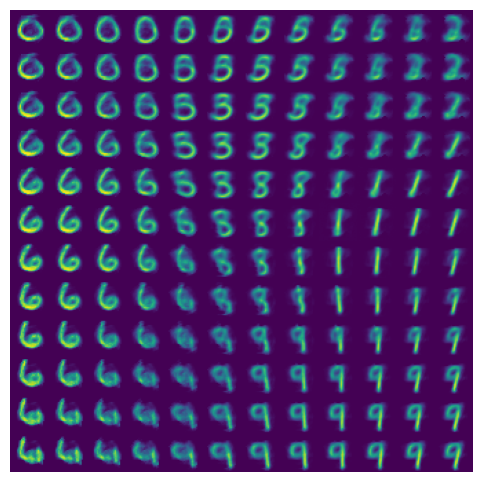

In [29]:
plot_reconstructed(autoencoder)

Можем наблюдать, что реконструированные векторы выглядят как цифры, но есть проблемы, где непонятно, что за цифра написана. Эта как раз проблема переобучения и выколотых точек в пространстве, с такой архитектурой сети невозможно генерировать объекты.  

## Задание 3
    3.1. Объясниет почему автоэнкодер группирует точки в латентном пространстве в соответствии с классами
    3.2. Объясните почему нет непрерывной интерполяции
    
    

### Задание 3.1: Почему автоэнкодер группирует точки в латентном пространстве в соответствии с классами

Автоэнкодер группирует точки в латентном пространстве в соответствии с классами по следующим причинам:

1. **Семантическая близость**: Объекты одного класса имеют схожие визуальные характеристики (например, все цифры "3" имеют похожую форму). Автоэнкодер учится кодировать эти общие паттерны в компактное представление.

2. **Минимизация ошибки реконструкции**: При обучении автоэнкодер минимизирует ошибку реконструкции. Поскольку объекты одного класса похожи, энкодер естественным образом помещает их близко друг к другу в латентном пространстве, чтобы декодер мог эффективно их реконструировать.

3. **Компрессия информации**: Энкодер вынужден сжимать информацию из 784 пикселей (28x28) в небольшое латентное пространство (например, 2 измерения). Это заставляет его находить общие паттерны и группировать похожие объекты вместе.

4. **Отсутствие явной регуляризации**: В отличие от VAE, обычный автоэнкодер не имеет явной регуляризации латентного пространства, что позволяет ему свободно организовывать точки, но при этом он естественным образом группирует похожие объекты для эффективной реконструкции.

5. **Нелинейные преобразования**: Слои с активациями (ReLU, sigmoid) позволяют модели находить нелинейные зависимости и создавать кластеры в латентном пространстве.


### Задание 3.2: Почему нет непрерывной интерполяции

В обычном автоэнкодере нет непрерывной интерполяции по следующим причинам:

1. **"Выколотые" области в латентном пространстве**: Автоэнкодер обучается только на реальных данных из обучающей выборки. В результате энкодер кодирует только те точки, которые он видел во время обучения. Области между кластерами классов остаются "пустыми" - там нет обученных представлений.

2. **Отсутствие регуляризации**: Обычный автоэнкодер не имеет регуляризации, которая бы заставляла латентное пространство быть непрерывным и плотным. В отличие от VAE, который использует KL-дивергенцию для регуляризации, автоэнкодер может создавать разрывы между кластерами.

3. **Переобучение на дискретных точках**: Модель переобучается на конкретных примерах из обучающей выборки, создавая острые пики в латентном пространстве. При интерполяции между двумя точками из разных классов мы попадаем в необученную область, где декодер не знает, что генерировать.

4. **Отсутствие априорного распределения**: В VAE есть априорное распределение (обычно стандартный нормальный), которое заставляет латентное пространство быть непрерывным. В обычном автоэнкодере такого ограничения нет.

5. **Нет гарантии гладкости**: Декодер не гарантирует, что близкие точки в латентном пространстве будут давать похожие реконструкции. Это приводит к резким переходам при интерполяции.

**Решение**: VAE решает эту проблему, добавляя регуляризацию через KL-дивергенцию, которая заставляет латентное пространство быть непрерывным и плотным, что позволяет генерировать новые объекты через интерполяцию.


### Variational Autoencoder (VAE)

Идея его следующая:

 - Есть некоторое заданное пространство Z, в котором у нас есть наше latent-представление.
 - Хотим что бы энкодер и декодер научились генерировать и распаковывать точки из него не только возле известных примеров,
 - Хотим покрыть это пространство наиболее плотно опираясь на распредление объектов в латентном пространстве

Вместо того, чтобы предсказывать один вектор или одну точку, будем предсказывать параметры распределения (область пространства).

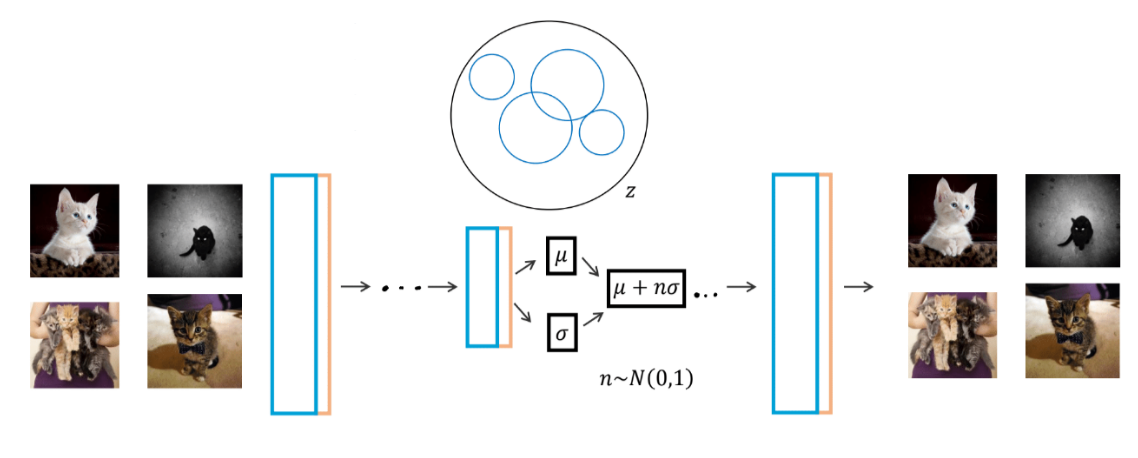

Для этого надо будет предсказать среднее и дисперсию: $$\mu,\sigma$$

Среднее будет соответствовать центру круга, а дисперсия - радиусу.

И затем на вход декодеру возьмем случайную точку в этом предсказанном кружке по формуле:

$$\mu + n\sigma\\n ~ N(0,1)$$

И этот декодер должен будет по нему реконструировать ту же картинку.

И наш лосс будет состоять из двух частей. Первый - это то что декодер может восстановить для этой случайной точки картинку:

$$L_r = ||x_{out} - x_{in}||^2$$

А второй лосс, будет стимулировать наш энкодер не делать слишком маленькие круги, а то мы вернемся к ситуации когда у нас точки, а не круги:
    
$$L_{KL} = D_{KL}(\mu, \sigma||N(0,1)) = \sum_{j=0}^{N}({\sigma_j}^2 + {\mu_j}^2 - log{\sigma_j}^2 - 0.5)$$

Дополительные ссылки:

[Оригинальная ссылка](https://arxiv.org/abs/1312.6114)  

[дивергенция KL и другие](https://ru.wikipedia.org/wiki/%D0%A0%D0%B0%D1%81%D1%81%D1%82%D0%BE%D1%8F%D0%BD%D0%B8%D0%B5_%D0%9A%D1%83%D0%BB%D1%8C%D0%B1%D0%B0%D0%BA%D0%B0_%E2%80%94_%D0%9B%D0%B5%D0%B9%D0%B1%D0%BB%D0%B5%D1%80%D0%B0)

[яндекс VAE](https://education.yandex.ru/handbook/ml/article/variational-autoencoder-(vae))

[VAE pytorch  много разных ](https://github.com/AntixK/PyTorch-VAE)

[теория и torch реализация VAE](https://jmtomczak.github.io/blog/4/4_VAE.html#There-are-many,-many-more!)

Чтобы реализовать вариационный автоэнкодер не нужно будет менять класс декодера, нужно только поменять класс энкодера выдавать два вектора - среднее и дисперсия, а затем использоваться эти статистики для сэмлирования вектора из скрытого пространства.

In [30]:
class VariationalEncoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalEncoder, self).__init__()
        self.linear1 = nn.Linear(784, 512)
        self.linear2 = nn.Linear(512, latent_dims)
        self.linear3 = nn.Linear(512, latent_dims)

        self.N = torch.distributions.Normal(0, 1)
        self.N.loc = self.N.loc.cuda() # hack to get sampling on the GPU
        self.N.scale = self.N.scale.cuda()
        self.kl = 0

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        mu = self.linear2(x)
        sigma = torch.exp(self.linear3(x))
        z = mu + sigma * self.N.sample(mu.shape)
        self.kl = (sigma ** 2 + mu ** 2 - torch.log(sigma) - 1/2).sum()
        return z

In [31]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalAutoencoder, self).__init__()
        self.encoder = VariationalEncoder(latent_dims)
        self.decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

Чтобы обучить вариационный автоэнкодер нужно добавить дополнительный лосс в обучающий алгоритм.

In [32]:
def train(autoencoder, data, epochs=20):
    opt = torch.optim.Adam(autoencoder.parameters())

    for epoch in range(epochs):
        for step, (x, _) in enumerate(data):
            x = x.to(device)
            opt.zero_grad()
            x_hat = autoencoder(x)
            l2_loss = ((x - x_hat) ** 2).sum()
            kl_loss = autoencoder.encoder.kl
            loss = l2_loss + kl_loss
            loss.backward()
            opt.step()

            if step % 200 == 0:
                print(f'Epoch [{epoch+1}/{epochs}]. Step [{step}/{len(data)}].', end=' ')
                print(f'Loss is {loss.item():.2f}. L2 loss is {l2_loss:.2f}. KL loss is {kl_loss:.2f}')

    return autoencoder

In [33]:
vae = VariationalAutoencoder(latent_dims).to(device)
vae = train(vae, data)

Epoch [1/20]. Step [0/235]. Loss is 47662.95. L2 loss is 47399.55. KL loss is 263.40
Epoch [1/20]. Step [200/235]. Loss is 12333.53. L2 loss is 11353.52. KL loss is 980.00
Epoch [2/20]. Step [0/235]. Loss is 11543.11. L2 loss is 10613.10. KL loss is 930.01
Epoch [2/20]. Step [200/235]. Loss is 11050.92. L2 loss is 10034.23. KL loss is 1016.69
Epoch [3/20]. Step [0/235]. Loss is 11062.87. L2 loss is 10023.54. KL loss is 1039.34
Epoch [3/20]. Step [200/235]. Loss is 10559.00. L2 loss is 9454.67. KL loss is 1104.32
Epoch [4/20]. Step [0/235]. Loss is 10776.41. L2 loss is 9671.91. KL loss is 1104.50
Epoch [4/20]. Step [200/235]. Loss is 10906.23. L2 loss is 9805.81. KL loss is 1100.42
Epoch [5/20]. Step [0/235]. Loss is 10778.07. L2 loss is 9730.70. KL loss is 1047.37
Epoch [5/20]. Step [200/235]. Loss is 10723.36. L2 loss is 9595.40. KL loss is 1127.96
Epoch [6/20]. Step [0/235]. Loss is 10760.51. L2 loss is 9540.02. KL loss is 1220.50
Epoch [6/20]. Step [200/235]. Loss is 10933.44. L2 lo

Снова посмотрим на скрытое пространство, но уже на вариационном автоэнкодере.

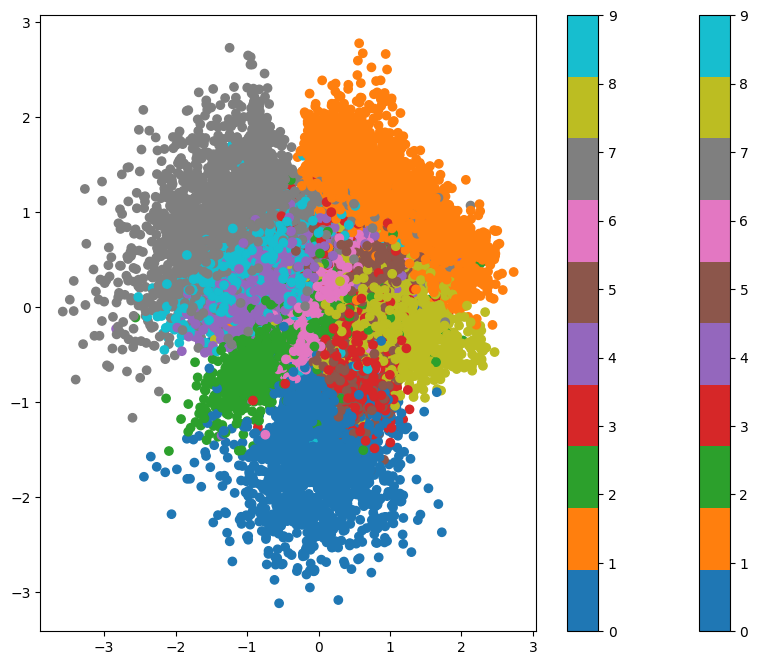

In [34]:
plot_latent(vae, data)

В сравнении с автоэнкодром, VAE выдает более центрированные области классов и они более сжатые.  
И посмотрим на реконструированные цифры из векторов скрытого пространства.

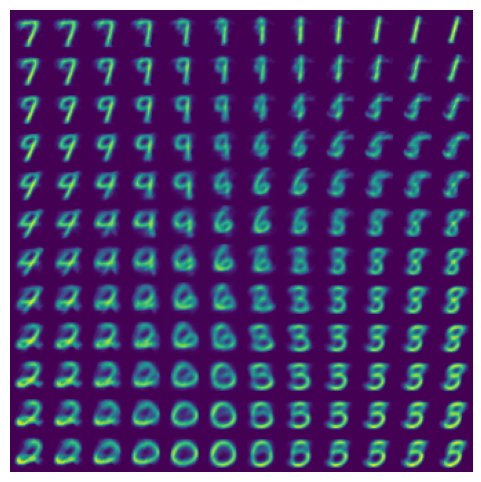

In [35]:
plot_reconstructed(vae, r0=(-1, 1), r1=(-1, 1))

## Задание 4.
    4.1. Постройте VAE для "рукописных цифр" и сравните результаты визуализации из латентного пространства с результатами Автоэнкодера, РСА, tSNE
    4.2. проведите эксперимент с параметрами обученияЖ скорость обучения [0.001, 0.00001, 0.1], числом эпох[1, 5, 10, 15, 20] - из

###  Интерполяции

Допустим у нас есть натренированный такой автоэнкодер. Что мы можем? Возьмем два лица. Представим их в latent-пространстве. Сравним их. И будем интерполировать: построим прямую через точки их представляющие, насэмплим точек по этой прямой и дадим нашему декодеру их декомпозировать. Получим примерно следующее:

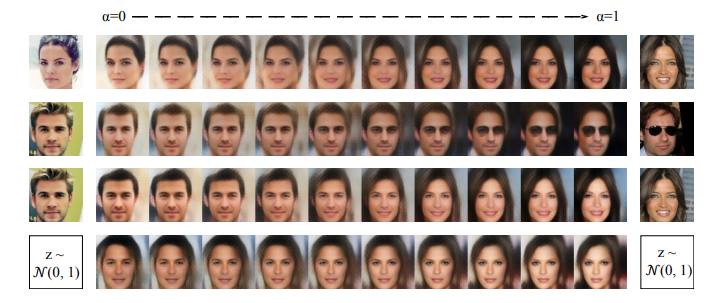

https://arxiv.org/abs/1610.00291

Посмотрим на интерполяцию наших цифр, возьмем два вектора - начало и конец генерации.

In [36]:
def interpolate(autoencoder, x_1, x_2, n=12):
    z_1 = autoencoder.encoder(x_1)
    z_2 = autoencoder.encoder(x_2)
    z = torch.stack([z_1 + (z_2 - z_1)*t for t in np.linspace(0, 1, n)])
    interpolate_list = autoencoder.decoder(z)
    interpolate_list = interpolate_list.to('cpu').detach().numpy()

    w = 28
    img = np.zeros((w, n*w))
    for i, x_hat in enumerate(interpolate_list):
        img[:, i*w:(i+1)*w] = x_hat.reshape(28, 28)
    plt.figure(figsize=(10, 2))
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])

In [37]:
for x, y in data: # hack to grab a batch
    x_1 = x[y == 1][1].to(device) # find a 1
    x_2 = x[y == 0][1].to(device) # find a 0
    break

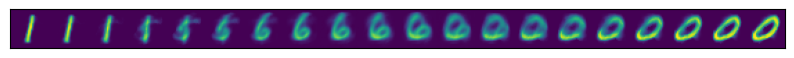

In [38]:
interpolate(vae, x_1, x_2, n=20)

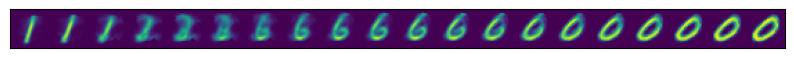

In [39]:
interpolate(autoencoder, x_1, x_2, n=20)

 анимацию переходов между реконструированными цифрами.

In [40]:
from PIL import Image

def interpolate_gif(autoencoder, filename, x_1, x_2, n=100):
    z_1 = autoencoder.encoder(x_1)
    z_2 = autoencoder.encoder(x_2)

    z = torch.stack([z_1 + (z_2 - z_1)*t for t in np.linspace(0, 1, n)])

    interpolate_list = autoencoder.decoder(z)
    interpolate_list = interpolate_list.to('cpu').detach().numpy()*255

    images_list = [Image.fromarray(img.reshape(28, 28)).resize((256, 256)) for img in interpolate_list]
    images_list = images_list + images_list[::-1] # loop back beginning

    images_list[0].save(
        f'{filename}.gif',
        save_all=True,
        append_images=images_list[1:],
        loop=1)

In [41]:
interpolate_gif(vae, "vae", x_1, x_2)

In [42]:
!ls

MNIST  sample_data  vae.gif


#### 2.3.1 Операции с latent space

Хотим найти в латентном пространстве некое направление, которое соотвествует некоторому признаку. Например, мы хотим понять направление признака, что на лице есть улыбка.
Для этого мы возьмем например 50 лиц, на которых есть улыбка и на которых нет. И посмотрим на наше пространство. Те лица, на которых нет улыбки находятся в одной части пространства. Те, где есть улыбка находятся в другой части пространства. Мы можем усреднить эти лица (с улыбкой и без) и сможем подсчитать вектор в направлении между этими точками в нашем пространстве. И сможем увидить, что декодер начинает генерировать более улыбающиеся лица.

Точно так же и сдругими признаками.

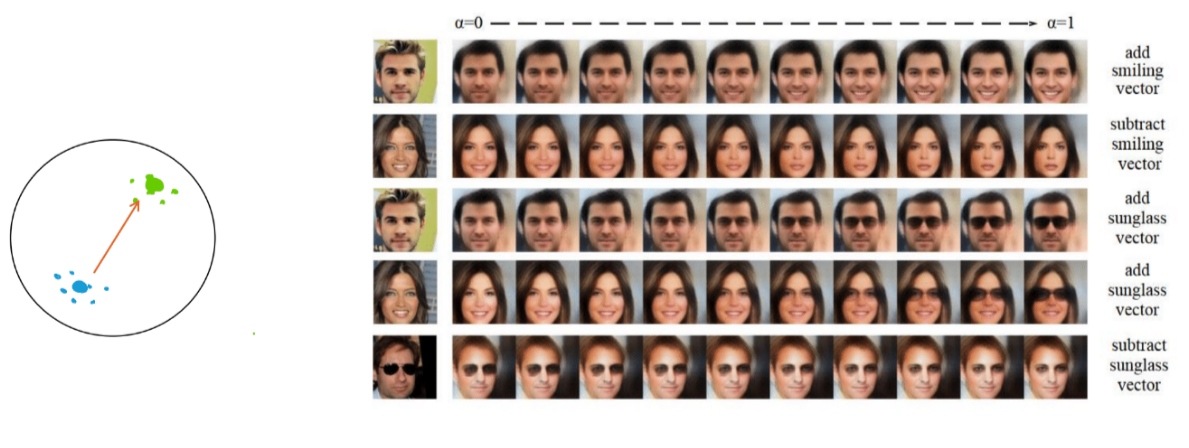

In [ ]:
# Задание 4.1: Построение VAE для рукописных цифр и сравнение визуализаций

# VAE уже построен и обучен выше (ячейка 77)
# Теперь сравним визуализации латентного пространства VAE с автоэнкодером, PCA и tSNE

print("Задание 4.1: Сравнение визуализаций латентного пространства")

# Визуализация латентного пространства VAE
print("\n1. Визуализация латентного пространства VAE:")
plot_latent(vae, data_test, num_batches=4)

# Визуализация латентного пространства автоэнкодера (если он еще доступен)
print("\n2. Визуализация латентного пространства автоэнкодера:")
if 'autoencoder' in locals():
    plot_latent(autoencoder, data_test, num_batches=4)

# PCA для эмбеддингов VAE
print("\n3. PCA для эмбеддингов VAE:")
def plot_latent_pca_vae(vae_model, data, num_samples=1000, device=device):
    """Визуализация латентного пространства VAE через PCA"""
    plt.figure(figsize=(10, 8))
    pca = PCA(n_components=2)
    rez = []
    rez_y = []
    count = 0
    
    for i, (x, y) in enumerate(data):
        z = vae_model.encoder(x.to(device))
        z = z.to('cpu').detach().numpy()
        rez.extend(z.tolist())
        rez_y.extend(y.tolist())
        count += len(y)
        if count >= num_samples:
            break
    
    rez = rez[:num_samples]
    rez_y = rez_y[:num_samples]
    
    Z = pca.fit_transform(np.array(rez))
    plt.scatter(Z[:, 0], Z[:, 1], c=rez_y, cmap='tab10', alpha=0.6)
    plt.colorbar(label='Класс')
    plt.title('PCA: Латентное пространство VAE (1000 образцов)')
    plt.xlabel('Первая главная компонента')
    plt.ylabel('Вторая главная компонента')
    plt.show()
    
    return Z, rez_y

Z_vae_pca, labels_vae = plot_latent_pca_vae(vae, data_test, num_samples=1000)


In [ ]:
# tSNE для эмбеддингов VAE
print("4. tSNE для эмбеддингов VAE:")
def plot_latent_tsne_vae(vae_model, data, num_samples=1000, device=device):
    """Визуализация латентного пространства VAE через tSNE"""
    plt.figure(figsize=(10, 8))
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    rez = []
    rez_y = []
    count = 0
    
    for i, (x, y) in enumerate(data):
        z = vae_model.encoder(x.to(device))
        z = z.to('cpu').detach().numpy()
        rez.extend(z.tolist())
        rez_y.extend(y.tolist())
        count += len(y)
        if count >= num_samples:
            break
    
    rez = rez[:num_samples]
    rez_y = rez_y[:num_samples]
    
    print("Выполняется tSNE для VAE... (это может занять некоторое время)")
    Z = tsne.fit_transform(np.array(rez))
    plt.scatter(Z[:, 0], Z[:, 1], c=rez_y, cmap='tab10', alpha=0.6)
    plt.colorbar(label='Класс')
    plt.title('tSNE: Латентное пространство VAE (1000 образцов)')
    plt.xlabel('Первая компонента tSNE')
    plt.ylabel('Вторая компонента tSNE')
    plt.show()
    
    return Z, rez_y

Z_vae_tsne, labels_vae_tsne = plot_latent_tsne_vae(vae, data_test, num_samples=1000)


In [ ]:
# Задание 4.2: Эксперимент с параметрами обучения

# Проводим эксперимент с различными скоростями обучения и числом эпох
learning_rates = [0.001, 0.00001, 0.1]
num_epochs_list = [1, 5, 10, 15, 20]

results = []

print("Задание 4.2: Эксперимент с параметрами обучения VAE")
print("=" * 60)

for lr in learning_rates:
    for epochs in num_epochs_list:
        print(f"\nОбучение VAE: LR={lr}, Epochs={epochs}")
        print("-" * 60)
        
        # Создаем новый VAE для каждого эксперимента
        vae_exp = VariationalAutoencoder(latent_dims=2).to(device)
        
        # Функция обучения с параметрами
        def train_vae_with_params(vae_model, data, epochs=20, lr=0.001):
            opt = torch.optim.Adam(vae_model.parameters(), lr=lr)
            
            final_loss = None
            for epoch in range(epochs):
                epoch_loss = 0
                for step, (x, _) in enumerate(data):
                    x = x.to(device)
                    opt.zero_grad()
                    x_hat = vae_model(x)
                    l2_loss = ((x - x_hat) ** 2).sum()
                    kl_loss = vae_model.encoder.kl
                    loss = l2_loss + kl_loss
                    loss.backward()
                    opt.step()
                    epoch_loss += loss.item()
                
                final_loss = epoch_loss / len(data)
                if epoch % max(1, epochs // 5) == 0 or epoch == epochs - 1:
                    print(f"  Epoch [{epoch+1}/{epochs}], Loss: {final_loss:.2f}")
            
            return vae_model, final_loss
        
        # Обучаем модель
        vae_exp, final_loss = train_vae_with_params(vae_exp, data, epochs=epochs, lr=lr)
        
        # Сохраняем результаты
        results.append({
            'lr': lr,
            'epochs': epochs,
            'final_loss': final_loss,
            'model': vae_exp
        })
        
        print(f"  Финальная потеря: {final_loss:.2f}")

print("\n" + "=" * 60)
print("Эксперимент завершен!")
print("\nСводка результатов:")
print("-" * 60)
for r in results:
    print(f"LR={r['lr']:8.5f}, Epochs={r['epochs']:2d}, Loss={r['final_loss']:.2f}")


Все хорошо, но стоит отметить, что все эти картинки получаются довольно размытыми. Почему это происходит?

Проблема в том, что функция по реконструкции - это L2. Т.е. она минимизирует расстояния. И в случае, когда мы не знаем, что предсказывать или в случае, когда много вариантов (бэкграунды везде разные) эффективнее всего предсказывать среднее. А среднее - это по определению размытие. И оказывается, что очень многие функции потерь этому подвержены.

In [ ]:
# Задание 5: FashionMNIST с автоэнкодером и VAE

# Загрузка FashionMNIST
from torchvision.datasets import FashionMNIST

transform_fashion = transforms.Compose([transforms.ToTensor()])

fashion_train = FashionMNIST(
    '.',
    train=True,
    download=True,
    transform=transform_fashion
)

fashion_test = FashionMNIST(
    '.',
    train=False,
    download=True,
    transform=transform_fashion
)

fashion_dataloader = torch.utils.data.DataLoader(
    fashion_train,
    batch_size=256,
    shuffle=True
)

fashion_test_loader = torch.utils.data.DataLoader(
    fashion_test,
    batch_size=256,
    shuffle=False
)

print("FashionMNIST загружен!")
print(f"Размер обучающей выборки: {len(fashion_train)}")
print(f"Размер тестовой выборки: {len(fashion_test)}")


In [ ]:
# Задание 5.1: Построение автоэнкодера для FashionMNIST с размером латентного пространства 2

latent_dims_fashion = 2

# Создаем автоэнкодер для FashionMNIST
fashion_autoencoder = Autoencoder(latent_dims_fashion).to(device)

print("Задание 5.1: Обучение автоэнкодера для FashionMNIST")
fashion_autoencoder = train(fashion_autoencoder, fashion_dataloader, epochs=10)

print("\nАвтоэнкодер обучен!")


In [ ]:
# Задание 5.1: Построение VAE для FashionMNIST с размером латентного пространства 2

# Создаем VAE для FashionMNIST
fashion_vae = VariationalAutoencoder(latent_dims_fashion).to(device)

print("Задание 5.1: Обучение VAE для FashionMNIST")

# Функция обучения VAE с KL-loss
def train_vae_fashion(vae_model, data, epochs=20):
    opt = torch.optim.Adam(vae_model.parameters())
    for epoch in range(epochs):
        for step, (x, _) in enumerate(data):
            x = x.to(device)
            opt.zero_grad()
            x_hat = vae_model(x)
            l2_loss = ((x - x_hat) ** 2).sum()
            kl_loss = vae_model.encoder.kl
            loss = l2_loss + kl_loss
            loss.backward()
            opt.step()
            if step % 200 == 0:
                print(f'Epoch [{epoch+1}/{epochs}]. Step [{step}/{len(data)}].', end=' ')
                print(f'Loss is {loss.item():.2f}. L2 loss is {l2_loss:.2f}. KL loss is {kl_loss:.2f}')
    return vae_model

fashion_vae = train_vae_fashion(fashion_vae, fashion_dataloader, epochs=10)

print("\nVAE обучен!")


In [ ]:
# Задание 5.2: Сравнение визуализаций в латентном пространстве

print("Задание 5.2: Сравнение визуализаций латентного пространства")
print("\n1. Визуализация латентного пространства автоэнкодера:")
plot_latent(fashion_autoencoder, fashion_test_loader, num_batches=4)

print("\n2. Визуализация латентного пространства VAE:")
plot_latent(fashion_vae, fashion_test_loader, num_batches=4)

# Сравнительная визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Автоэнкодер
for i, (x, y) in enumerate(fashion_test_loader):
    z = fashion_autoencoder.encoder(x.to(device))
    z = z.to('cpu').detach().numpy()
    axes[0].scatter(z[:, 0], z[:, 1], c=y, cmap='tab10', alpha=0.6)
    if i > 3:
        break
axes[0].set_title('Автоэнкодер: Латентное пространство FashionMNIST')
axes[0].set_xlabel('z1')
axes[0].set_ylabel('z2')
axes[0].grid(True, alpha=0.3)

# VAE
for i, (x, y) in enumerate(fashion_test_loader):
    z = fashion_vae.encoder(x.to(device))
    z = z.to('cpu').detach().numpy()
    axes[1].scatter(z[:, 0], z[:, 1], c=y, cmap='tab10', alpha=0.6)
    if i > 3:
        break
axes[1].set_title('VAE: Латентное пространство FashionMNIST')
axes[1].set_xlabel('z1')
axes[1].set_ylabel('z2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Задание 5.3, 5.4, 5.5: Оценка по метрике FID

# Для расчета FID нужна предобученная модель (например, Inception)
# Устанавливаем pytorch-ignite для FID метрики
try:
    from ignite.metrics import FID
    from ignite.contrib.metrics import GANMetric
    print("pytorch-ignite доступен для расчета FID")
except ImportError:
    print("Внимание: pytorch-ignite не установлен. Установите его командой: pip install pytorch-ignite")
    print("Для выполнения заданий 5.3-5.5 необходимо установить pytorch-ignite")

# Альтернативная реализация FID (упрощенная версия)
def calculate_fid_simple(real_images, fake_images):
    """
    Упрощенная версия FID метрики
    В реальной задаче лучше использовать готовую библиотеку
    """
    # Преобразуем в numpy
    if isinstance(real_images, torch.Tensor):
        real_images = real_images.cpu().numpy()
    if isinstance(fake_images, torch.Tensor):
        fake_images = fake_images.cpu().numpy()
    
    # Вычисляем среднее и ковариацию
    mu_real = np.mean(real_images.reshape(len(real_images), -1), axis=0)
    mu_fake = np.mean(fake_images.reshape(len(fake_images), -1), axis=0)
    
    sigma_real = np.cov(real_images.reshape(len(real_images), -1).T)
    sigma_fake = np.cov(fake_images.reshape(len(fake_images), -1).T)
    
    # Упрощенный расчет FID (без Inception сети)
    diff = mu_real - mu_fake
    covmean = (sigma_real @ sigma_fake) ** 0.5
    fid = np.sum(diff ** 2) + np.trace(sigma_real + sigma_fake - 2 * covmean)
    
    return fid

print("\nЗадание 5.3: Оценка FID в области основных концентраций объектов")
print("=" * 60)

# Генерируем изображения из областей основных концентраций
# (вокруг центра латентного пространства)
num_samples_fid = 1000

# Реальные изображения из тестовой выборки
real_images_fashion = []
for x, _ in fashion_test_loader:
    real_images_fashion.append(x)
    if len(real_images_fashion) * x.shape[0] >= num_samples_fid:
        break
real_images_fashion = torch.cat(real_images_fashion[:num_samples_fid // 256 + 1], dim=0)[:num_samples_fid]

# Генерируем изображения из автоэнкодера (в области основных концентраций)
z_autoencoder = torch.randn(num_samples_fid, latent_dims_fashion).to(device) * 0.5  # Вокруг центра
with torch.no_grad():
    fake_images_ae = fashion_autoencoder.decoder(z_autoencoder)

# Генерируем изображения из VAE (в области основных концентраций)
z_vae = torch.randn(num_samples_fid, latent_dims_fashion).to(device) * 0.5  # Вокруг центра
with torch.no_grad():
    fake_images_vae = fashion_vae.decoder(z_vae)

# Вычисляем FID
fid_ae_main = calculate_fid_simple(real_images_fashion, fake_images_ae)
fid_vae_main = calculate_fid_simple(real_images_fashion, fake_images_vae)

print(f"FID автоэнкодер (основные области): {fid_ae_main:.2f}")
print(f"FID VAE (основные области): {fid_vae_main:.2f}")


In [ ]:
print("\nЗадание 5.4: Оценка FID за границами основных областей")
print("=" * 60)

# Генерируем изображения из больших значений латентного вектора (за границами)
z_autoencoder_large = torch.randn(num_samples_fid, latent_dims_fashion).to(device) * 3.0  # Большие значения
with torch.no_grad():
    fake_images_ae_large = fashion_autoencoder.decoder(z_autoencoder_large)

z_vae_large = torch.randn(num_samples_fid, latent_dims_fashion).to(device) * 3.0  # Большие значения
with torch.no_grad():
    fake_images_vae_large = fashion_vae.decoder(z_vae_large)

# Вычисляем FID
fid_ae_boundary = calculate_fid_simple(real_images_fashion, fake_images_ae_large)
fid_vae_boundary = calculate_fid_simple(real_images_fashion, fake_images_vae_large)

print(f"FID автоэнкодер (за границами): {fid_ae_boundary:.2f}")
print(f"FID VAE (за границами): {fid_vae_boundary:.2f}")

print("\nВывод:")
print(f"В основных областях: VAE показывает {'лучший' if fid_vae_main < fid_ae_main else 'худший'} результат")
print(f"За границами: VAE показывает {'лучший' if fid_vae_boundary < fid_ae_boundary else 'худший'} результат")


In [ ]:
print("\nЗадание 5.5: Оценка изменения FID для различных размеров латентного пространства")
print("=" * 60)

latent_dims_list = [2, 3, 5, 10, 20]
fid_results = []

for latent_dim in latent_dims_list:
    print(f"\nЭксперимент с размером латентного пространства: {latent_dim}")
    print("-" * 60)
    
    # Создаем и обучаем VAE с разными размерами латентного пространства
    vae_dim = VariationalAutoencoder(latent_dims=latent_dim).to(device)
    vae_dim = train_vae_fashion(vae_dim, fashion_dataloader, epochs=5)  # Обучаем меньше для скорости
    
    # Генерируем изображения в основных областях
    z_dim = torch.randn(num_samples_fid, latent_dim).to(device) * 0.5
    with torch.no_grad():
        fake_images_dim = vae_dim.decoder(z_dim)
    
    # Вычисляем FID
    fid_dim = calculate_fid_simple(real_images_fashion, fake_images_dim)
    fid_results.append({'latent_dim': latent_dim, 'fid': fid_dim})
    
    print(f"FID для latent_dim={latent_dim}: {fid_dim:.2f}")

print("\n" + "=" * 60)
print("Результаты экспериментов:")
print("-" * 60)
for r in fid_results:
    print(f"Latent dim: {r['latent_dim']:2d}, FID: {r['fid']:.2f}")

# Визуализация результатов
plt.figure(figsize=(10, 6))
latent_dims_vals = [r['latent_dim'] for r in fid_results]
fid_vals = [r['fid'] for r in fid_results]
plt.plot(latent_dims_vals, fid_vals, marker='o', linewidth=2, markersize=8)
plt.xlabel('Размер латентного пространства')
plt.ylabel('FID')
plt.title('Зависимость FID от размера латентного пространства')
plt.grid(True, alpha=0.3)
plt.show()

print("\nВывод: Как правило, с увеличением размера латентного пространства")
print("FID улучшается (уменьшается), так как модель может лучше кодировать информацию.")


**Метрика качества генерации объектов**
    FID (Fréchet inception distance) - сравнивает распределение сгенерированных изображений с распределением набора реальных изображений (набора «истинных» данных). Вместо сравнения отдельных изображений, среднее значение и ковариационная статистика множества изображений, сгенерированных моделью, сравниваются с той же статистикой, полученной из изображений из набора «истинных» данных или эталонного набора. Для получения высокоуровневых признаков, описывающих изображения, используется сверточная нейронная сеть.
    
[FID описание](https://en.wikipedia.org/wiki/Fr%C3%A9chet_inception_distance)

[FID реализация из пакета](https://docs.pytorch.org/ignite/generated/ignite.metrics.FID.html)

[FID torch реализация](https://docs.pytorch.org/ignite/_modules/ignite/metrics/gan/fid.html)


<h1><center>Часть 2. Практика</center></h1>

# Задание 5
    5.1. Для данных fashionMNIST построить  Автоэнкодер и  VAE с размером латентного пространства 2
    5.1. Сравнить визуализации в латентном пространства
    5.3. Оценить визуализацию в области основных концентраций объектов по метрике FID
    5.4. Оценить визуализацию за границами основных областей (большие значения латентного вектора подать на декодер и оценить результат по метрике FID)
    5.5. Оценить изменение FID для изменения размера латентного пространства из нескольких перезапусков: [2, 3, 5, 10, 20]
    
    
[fashionMNIST](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html)     